<a href="https://colab.research.google.com/github/prantik1998/playwithlllms/blob/main/docs/core/gemma_library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 Google LLC.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Prompt with images and text using Gemma library

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemma/docs/core/gemma_library"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on ai.google.dev</a>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemma/cookbook/blob/main/docs/core/gemma_library.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/google-gemma/cookbook/blob/main/docs/core/gemma_library.ipynb"><img src="https://www.kaggle.com/static/images/logos/kaggle-logo-transparent-300.png" height="32" width="70"/>Run in Kaggle</a>
  </td>
  <td>
    <a target="_blank" href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fgoogle-gemma%2Fcookbook%2Fmain%2Fdocs%2Fcore%2Fgemma_library.ipynb"><img src="https://ai.google.dev/images/cloud-icon.svg" width="40" />Open in Vertex AI</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google-gemma/cookbook/blob/main/docs/core/gemma_library.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

Using images for prompting Gemma models opens up a whole new range of possibilies for understanding your world and solving problems with visual data. Starting with [Gemma 3](/gemma/docs/core) in 4B sizes and higher, you can use image data as part of your prompt to for richer context and to solve more complex tasks.

This tutorial shows you how to prompt Gemma with images using the [Gemma library](https://gemma-llm.readthedocs.io/) for JAX. Gemma library is a Python package built as an extension of [JAX](https://github.com/jax-ml/jax), letting you use the performance advantages of the JAX framework with dramatically less code.

Note: For more the up-to-data information this library, see the [Gemma library](https://gemma-llm.readthedocs.io/) documentation.

## Setup

To complete this tutorial, you'll first need to complete the setup instructions at [Gemma setup](https://ai.google.dev/gemma/docs/setup). The Gemma setup instructions show you how to do the following:

* Get access to Gemma on [kaggle.com](https://www.kaggle.com).
* Select a Colab runtime with sufficient resources to run
  the Gemma model.
* Generate and configure a Kaggle username and API key.

After you've completed the Gemma setup, move on to the next section, where you'll set environment variables for your Colab environment.

### Install libraries

Install the Gemma library.

In [2]:
!pip install -q gemma

### Set environment variables

Login with your Kaggle account.

Set the JAX environment to use the full GPU memory space.

In [3]:
import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]="1.00"

### Import packages

Import the Gemma library and additional support libraries.

In [1]:
# Common imports
import os
import jax
import jax.numpy as jnp
import tensorflow_datasets as tfds

# Gemma imports
from gemma import gm

## Configure a model

Select and configure a Gemma model for use, including a tokenizer, model architecture, and checkpoints. The Gemma libary supports all of Google's official releases of the model. You must use the `Gemma3Tokenizer` and a Gemma 3 or later model to be able to process images as part of your prompt.

To configure the model, run the following code:

In [2]:
tokenizer = gm.text.Gemma3Tokenizer()


In [7]:
!pip uninstall -y tensorflow tensorflow-cpu tf-nightly

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Found existing installation: tensorflow_cpu 2.21.0
Uninstalling tensorflow_cpu-2.21.0:
  Successfully uninstalled tensorflow_cpu-2.21.0


In [8]:
!pip install -U tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl (572.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.


In [3]:

model = gm.nn.Gemma3_4B()



In [4]:
params = gm.ckpts.load_params(gm.ckpts.CheckpointPath.GEMMA3_4B_IT)

In [12]:
!pip uninstall -y \
    jax \
    jaxlib \
    jax-cuda12-plugin \
    jax-cuda12-pjrt

Found existing installation: jax 0.10.2
Uninstalling jax-0.10.2:
  Successfully uninstalled jax-0.10.2
Found existing installation: jaxlib 0.10.2
Uninstalling jaxlib-0.10.2:
  Successfully uninstalled jaxlib-0.10.2
Found existing installation: jax-cuda12-plugin 0.7.2
Uninstalling jax-cuda12-plugin-0.7.2:
  Successfully uninstalled jax-cuda12-plugin-0.7.2
Found existing installation: jax-cuda12-pjrt 0.7.2
Uninstalling jax-cuda12-pjrt-0.7.2:
  Successfully uninstalled jax-cuda12-pjrt-0.7.2


In [13]:
!pip install -U "jax[cuda12]"

  Using cached jax-0.10.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.2-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
Using cached jax-0.10.2-py3-none-any.whl (3.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 132.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 MB 75.3 MB/s  0:00:02
Using cached jaxlib-0.10.2-cp312-cp312-manylinux_2_27_x86_64.whl (85.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jax]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kauldron 1.4.4 requires tensorflow-cpu, which is not installed.


## Generate text with text

Start by prompting with text. The Gemma library provides a Sampler function for simple prompting.

In [18]:
sampler = gm.text.ChatSampler(
    model=model,
    params=params,
    tokenizer=tokenizer,
)

sampler.chat('who is obama?.', max_new_tokens=200)

JaxRuntimeError: INTERNAL: Autotuning failed for HLO: %custom-call.477 = (f32[262144]{0}, s8[4194304]{0}) custom-call(%loop_convert_fusion.68, %bitcast.6889.0), custom_call_target="__cublas$lt$matmul", metadata={op_name="jit(__call__)/Gemma3_4B/embedder.decode/dot_general" stack_frame_id=182}, backend_config={"operation_queue_id":"0","gemm_backend_config":{"alpha_real":1,"beta":0,"dot_dimension_numbers":{"lhs_contracting_dimensions":["0"],"rhs_contracting_dimensions":["0"],"lhs_batch_dimensions":[],"rhs_batch_dimensions":[]},"alpha_imag":0,"precision_config":{"operand_precision":["DEFAULT","DEFAULT"],"algorithm":"ALG_UNSET"},"epilogue":"DEFAULT","lhs_stride":"2560","rhs_stride":"671088640","grad_x":false,"grad_y":false,"damax_output":false,"autotune_workspace_size":"0","scale_mode":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}. Failed to profile configs: Out of memory while trying to allocate 2.52GiB.

Change the prompt and change the maximum number of tokens to generate different output.

## Generate text with images

Once you have a text prompt working, you can add images to your prompt. Make sure you have configure a Gemma 3 or later model that is 4B or higher, and configured the `Gemma3Tokenizer`.

### Load an image

Load an image from a data source or a local file. The following code shows how to load an image from a TensorFlow datasource:

In [8]:
ds = tfds.data_source('oxford_flowers102', split='train')
image = ds[0]['image']

# display the image
image[:100,100,:]

array([[1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [2, 2, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1,

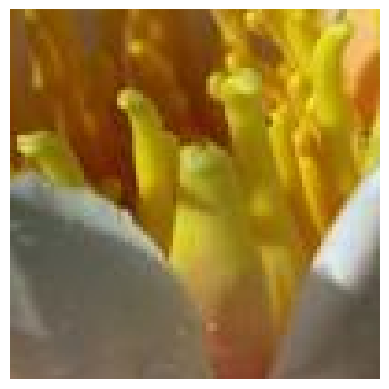

In [11]:
import matplotlib.pyplot as plt

plt.imshow(image[200:300,300:400,:])
plt.axis("off")
plt.show()

### Prepare prompt with image data

When you prompt with image data, you include a specific tag `<start_of_image>`, to include the image with the text your prompt. You then encode the prompt with the image data using the `tokenizer` object to prepare to run it with the model.

In [6]:
prompt = """<start_of_turn>user
Describe the contents of this image.

<start_of_image>

<end_of_turn>
<start_of_turn>model
"""

If you want to prompt with more than one image, you must include a `<start_of_image>` tag for each image included in your prompt.

### Run the prompt with image data

After you prepare your image data and the prompt with image tags, you can run the prompt and generate output. The following code shows how to use the `Sampler` function run the prompt:

In [15]:
sampler = gm.text.ChatSampler(
    model=model,
    params=params,
    tokenizer=tokenizer,
)


out = sampler.sample(prompt, images=image[200:300,300:400,:], max_new_tokens=50)
print(out)

AttributeError: 'ChatSampler' object has no attribute 'sample'

In [13]:
import jax

jax.clear_caches()

Alternatively, you can use the `gm.text.ChatSampler()` function generate a response without requiring `<start_of_turn>` tags. For more details, see the [Gemma library for JAX](https://gemma-llm.readthedocs.io/) documentation.

## Next steps

The Gemma library provides much more additional functionality. See these additional resources for more information:

*   [Gemma library sampling](https://gemma-llm.readthedocs.io/en/latest/colab_sampling.html)
*   [Gemma library finetuning](https://gemma-llm.readthedocs.io/en/latest/colab_finetuning.html)

The Gemma library for JAX provides additional functionality, including LoRA, Sharding, Quantization and more. For more details, see the [Gemma library](https://gemma-llm.readthedocs.io) documentation. If you have any feedback, or have issues using Gemma library, submit them through the repository [Issues](https://github.com/google-deepmind/gemma/issues) interface.
